# CIS 5200: Machine Learning
## Homework 1

# k-Nearest Neighbors (kNN) with the Wine Dataset

In this exercise, you will explore the kNN algorithm on the UCI Wine dataset.  
Unlike a toy dataset, this one has **13 continuous features** (chemical properties of wine) and **3 classes** (wine cultivars).  

We will focus not only on implementing kNN, but also on understanding:
- What the dataset looks like and what challenges it poses.
- How preprocessing affects kNN performance.
- How to interpret results and reflect on whether kNN was a good idea.

# IMPORTANT!!! MUST READ:
- You only have to implement the parts that say "TODO"
- Remember to run all cells.
- Answer Questions 1-6 in your written homework.


## Learning Goals

By the end of this notebook, you should be able to:

1. **Inspect and interpret a dataset** before applying a distance-based method.
   - Check class balance, feature scales, and correlations.
2. **Preprocess features appropriately** for kNN.
   - Understand why normalization matters.
3. **Analyze results after training**.
   - Use confusion matrices and per-class errors.
   - Compare nearest and farthest neighbor distances.
4. **Implement and tune kNN** with different values of *k*.
   - Evaluate using validation accuracy, not just training accuracy.
5. **Reflect on limitations** of kNN.
   - Consider the curse of dimensionality and sensitivity to irrelevant features.

## Setup

We will use:
- `scikit-learn` for loading the dataset and splitting data.
- `pandas` for exploring the dataset.
- `torch` for vectorized implementations later.

**Your task:** Follow the prompts. Do not just run cells—interpret outputs and answer reflection questions.


#Download the Dataset

In [ ]:
from sklearn.datasets import load_wine
import pandas as pd

# Load the Wine dataset
data = load_wine()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

# Wrap into a DataFrame for easier inspection
df = pd.DataFrame(X, columns=feature_names)
df["class"] = y

print("Dataset shape:", df.shape)
print("Class distribution:\n", df["class"].value_counts())

df.describe()

# QUESTION 1:
# a) How many samples are there?
# b) Are the classes balanced?
# c) Which features have the largest or smallest ranges?
# d) How might this affect Euclidean distance?

Dataset shape: (178, 14)
Class distribution:
 class
1    71
0    59
2    48
Name: count, dtype: int64


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch

# Train/val/test split
def split_data(X, y, test_size=0.2, seed=42):
    """
    Split features and labels into train/test sets.
    Use stratify=y and random_state=seed.
    Returns: train_x, test_x, train_y, test_y (numpy arrays).
    """
    # TODO: implement using train_test_split
    train_x, test_x, train_y, test_y = train_test_split(X, y, test_size=test_size, random_state=seed, stratify=y)
    return train_x, test_x, train_y, test_y


# Scaling
def scale_data(train_x, test_x):
    """
    Standardize features: mean=0, std=1.
    Fit scaler on train_x only, then transform both train_x and test_x.
    Returns: scaled train_x, scaled test_x (numpy arrays).
    """
    # TODO: implement using StandardScaler
    scaler = StandardScaler()
    train_x = scaler.fit_transform(train_x)
    test_x = scaler.transform(test_x)
    return train_x, test_x


# Torch conversion
def to_torch(train_x, test_x, train_y, test_y):
    """
    Convert numpy arrays to torch tensors.
    - Features: dtype=torch.float32
    - Labels: dtype=torch.long
    """
    # TODO: implement torch.tensor() conversions
    train_x = torch.tensor(train_x, dtype=torch.float32)
    test_x = torch.tensor(test_x, dtype=torch.float32)
    train_y = torch.tensor(train_y, dtype=torch.long)
    test_y = torch.tensor(test_y, dtype=torch.long)
    return train_x, test_x, train_y, test_y

# QUESTION 2:
# a) Why do we fit the scaler only on the training data, not the test data?
# b) Did scaling change the information in the dataset, or just its representation?

In [ ]:
# Run when methods above are implemented

train_x, test_x, train_y, test_y = split_data(X, y)
train_x, test_x = scale_data(train_x, test_x)
train_x, test_x, train_y, test_y = to_torch(train_x, test_x, train_y, test_y)

In [ ]:
# Test cases (DO NOT EDIT)

# 1. Shape checks
assert train_x.shape[0] > test_x.shape[0], "Train set should be larger than test set."
assert train_x.shape[1] == test_x.shape[1] == X.shape[1], "Feature dimension mismatch."
assert train_y.shape[0] == train_x.shape[0], "Train features/labels mismatch."
assert test_y.shape[0] == test_x.shape[0], "Test features/labels mismatch."

# 2. Data types
assert train_x.dtype == torch.float32, "Train features must be float32."
assert test_y.dtype == torch.long, "Test labels must be long."

# 3. Class balance
train_classes, test_classes = train_y.unique().tolist(), test_y.unique().tolist()
assert set(train_classes) == set(test_classes) == set(range(len(target_names))), \
    "Both train and test sets should contain all classes."

# 4. Scaling sanity checks
# Convert back to numpy for stats
train_x_np = train_x.numpy()
means = train_x_np.mean(axis=0)
stds = train_x_np.std(axis=0)

assert (abs(means) < 1e-6).all(), "Train features should have mean ~ 0 after scaling."
assert (abs(stds - 1) < 1e-6).all(), "Train features should have std ~ 1 after scaling."

print("All tests passed! Your split, scaling, and torch conversion look correct.")

All tests passed! Your split, scaling, and torch conversion look correct.


## PCA Visualization

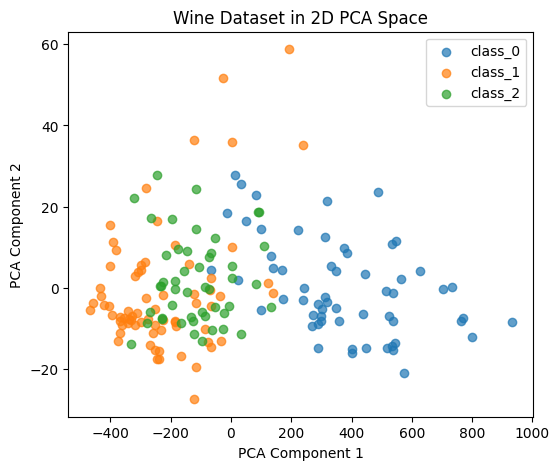

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA scatter plot (2D)
def plot_pca_scatter(X, y, target_names, seed=42):
    """
    Fit PCA to reduce features to 2D, then scatter plot colored by class.
    """
    pca = PCA(n_components=2, random_state=seed)
    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(6, 5))
    for class_idx, class_name in enumerate(target_names):
        mask = (y == class_idx)
        plt.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            label=class_name, alpha=0.7
        )
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title("Wine Dataset in 2D PCA Space")
    plt.legend()
    plt.show()

    return pca

# TODO: uncomment code below
pca = plot_pca_scatter(X, y, target_names)

# QUESTION 3:
# a) Are the classes fully separable in 2D? Or do you see overlaps?
# b) Which classes seem harder to distinguish visually?
# c) What might this imply about kNN’s confusion matrix later?


### Reflection on PCA Scatter

> **Note:** We haven’t formally covered PCA in this class yet. You do not have to fully understand the given code.
> Here we’re just using it as a visualization tool to get some intuition about the dataset. PCA gives us a way to look at the dataset from the perspective (axes) that capture the most variation in the features. Often, this also makes the classes look as separated as possible in just two dimensions. It doesn’t guarantee perfect separation, but it’s **the best 2D ‘snapshot’ of a 13D dataset**.

- **What PCA does (in plain terms):**  
  PCA finds new axes (called *components*) that are linear combinations of the original 13 features.  
  - The **1st component (x-axis in the plot)** is the single direction that explains the most variation in the dataset.  
  - The **2nd component (y-axis in the plot)** is the next-most important direction, at a right angle to the first.  
  - Together, these two axes let us approximate the 13D data in a 2D plot.

- **What the scatter plot shows:**  
  - Each point = one wine sample.  
  - **Color = true class label** (red = class 0, green = class 1, blue = class 2).  
  - PCA itself does *not* use these labels — they are added only for visualization.  
  - If the colors cluster apart, it means the dataset has some natural structure.  
  - If the colors overlap, it means the classes are not cleanly separated.

# k-Nearest Neighbors (kNN) Classifier

In this question, you will implement a kNN classifier for the Wine Dataset.

## (a) Implementation
- We will use Euclidean distance as our distance metric. We've given you a template for the actual algorithm, but you'll have to implement the guts of the algorithm yourself! Unfortunately, since being able to program in PyTorch while effectively using broadcasting and other matrix operations is really important if you want to do machine learning, you'll need to implement the distance computation yourself without using `torch.cdist` or other similar
functions.

In [ ]:
import numpy as np

def knn_distance_matrix(train_x: torch.Tensor, test_x: torch.Tensor) -> torch.Tensor:
    """
    Compute pairwise Euclidean distances between each test point and each train point.

    Args:
        train_x: (m_train, d) float32 tensor
        test_x:  (n_test,  d) float32 tensor

    Returns:
        D: (m_train, n_test) float32 tensor where D[i, j] = ||train_x[i] - test_x[j]||_2

    Hints:
        - Avoid loops. Use the squared-norm trick:
            ||a - b||^2 = ||a||^2 + ||b||^2 - 2 a·b
        - Compute rowwise squared norms with .pow(2).sum(dim=1, keepdim=True)
        - Use matrix multiply for the dot products.
        - Clamp small negatives to 0 before sqrt for numerical stability.
    """
    # TODO: ensure float32 - Handled in to_torch function
    # TODO: compute train_sq (m,1) and test_sq (1,n)
    # TODO: compute D2 = train_sq + test_sq - 2 * train_x @ test_x.T
    # TODO: clamp_min(0) then sqrt
    train_sq = torch.sum(train_x**2, dim=1, keepdim=True)
    test_sq = torch.sum(test_x**2, dim=1, keepdim=True).T
    D2 = train_sq + test_sq - 2 * train_x @ test_x.T
    D2 = torch.clamp_min(D2, 0)
    D = torch.sqrt(D2)
    return D


def knn_find_k_nearest_neighbors(D: torch.Tensor, k: int) -> torch.Tensor:
    """
    For each test column in D (m_train x n_test), return indices of the k nearest train points.

    Args:
        D: (m_train, n_test) distance matrix
        k: number of neighbors

    Returns:
        knn_inds: (n_test, k) LongTensor of row indices into the training set.

    Hints:
        - You want the k smallest distances per test point.
        - Consider transposing D and using torch.topk(..., largest=False, dim=1).
    """
    # TODO: assert valid k
    # TODO: top-k on the right dimension and return indices
    assert k <= D.shape[0], "k must be less than or equal to the number of train points."
    D_transposed = D.t()
    _, knn_inds = torch.topk(D_transposed, k=k, largest=False, dim=1)
    return knn_inds


def knn_predict(train_y: torch.Tensor, knn_inds: torch.Tensor) -> torch.Tensor:
    """
    Majority-vote prediction given neighbor indices.

    Args:
        train_y:  (m_train,) LongTensor of class labels starting at 0
        knn_inds: (n_test, k)  LongTensor of indices into the training set

    Returns:
        pred_y:   (n_test,)    LongTensor of predicted labels

    Hints:
        - Gather neighbor labels with train_y[knn_inds] -> shape (n_test, k)
        - Option A: use per-row bincount then argmax (deterministic tie-break: lowest class index).
        - Option B: torch.mode(neighbor_labels, dim=1).values (tie behavior may differ by PyTorch version).
        - Use dtype Long for labels.
    """
    # TODO: implement majority vote (prefer bincount for deterministic tie-break)
    neighbor_labels = train_y[knn_inds]
    pred_y = torch.mode(neighbor_labels, dim=1).values
    return pred_y


def knn_algorithm(train_x: torch.Tensor, test_x: torch.Tensor, train_y: torch.Tensor, k: int = 3) -> torch.Tensor:
    """
    Full kNN prediction pipeline (distance -> neighbors -> vote).
    Returns:
        pred_y: (n_test,) LongTensor
    """
    # TODO: call your three helpers in order
    D = knn_distance_matrix(train_x, test_x)
    knn_inds = knn_find_k_nearest_neighbors(D, k)
    pred_y = knn_predict(train_y, knn_inds)
    return pred_y

In [ ]:
# Evaluate kNN on the test set

# TODO: call your knn_algorithm with train_x, test_x, train_y
# Choose a value of k (try k=3 first, then experiment with others)
# Example: predictions = knn_algorithm(train_x, test_x, train_y, k=?)
k = 3
predictions = knn_algorithm(train_x, test_x, train_y, k)
print(f"Predictions: {predictions}")

# TODO: compute test accuracy by comparing predictions to test_y
# Hint: (predictions == test_y).float().mean()
test_accuracy = (predictions == test_y).float().mean()
print(f"Test Accuracy: {test_accuracy:.4f}")

# QUESTION 4:
# a) How does your accuracy compare to a simple majority-class baseline?
# b) Use the code block below to visualize several values of k (1, 3, 5, 11...). Does performance improve or worsen?
# c) What might explain the trend you see as k increases?


Predictions: tensor([0, 2, 0, 0, 1, 0, 0, 1, 1, 2, 1, 2, 0, 2, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0,
        1, 1, 0, 2, 1, 2, 0, 2, 1, 2, 2, 2])
Test Accuracy: 0.9722


## Confusion Matrix

Confusion matrix (rows=true, cols=pred):
 [[12  0  0]
 [ 1 13  0]
 [ 0  0 10]]

Per-class accuracy: [1.    0.929 1.   ]
Per-class error:    [0.    0.071 0.   ]

Detailed report:
               precision    recall  f1-score   support

     class_0      0.923     1.000     0.960        12
     class_1      1.000     0.929     0.963        14
     class_2      1.000     1.000     1.000        10

    accuracy                          0.972        36
   macro avg      0.974     0.976     0.974        36
weighted avg      0.974     0.972     0.972        36


--- Distance diagnostics ---
Nearest-neighbor distance
  mean(correct)   = 1.8929 | mean(incorrect)   = 3.9640
  p50(correct)    = 1.8373 | p50(incorrect)    = 3.9640
  p90(correct)    = 2.3231 | p90(incorrect)    = 3.9640
  max(correct)    = 2.8445 | max(incorrect)    = 3.9640
Farthest-of-k distance
  mean(correct)   = 2.2745 | mean(incorrect)   = 4.8933
  p50(correct)    = 2.1907 | p50(incorrect)    = 4.8933
  p90(correct)    = 2.775

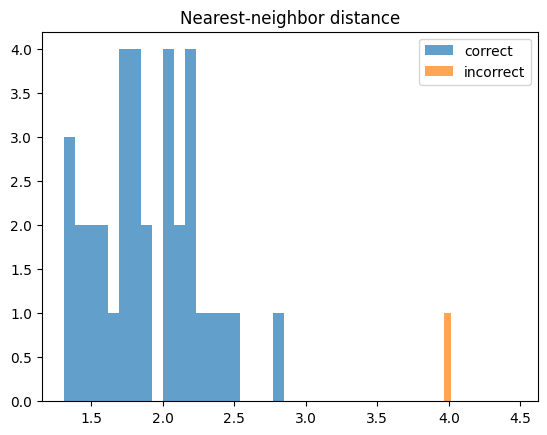

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Choose k
k_best = 3 # Use this for now

# kNN predictions on TEST
with torch.no_grad():
    D_test = knn_distance_matrix(train_x, test_x)                 # (n_train x n_test)
    knn_inds_test = knn_find_k_nearest_neighbors(D_test, k_best)  # (n_test x k)
    preds = knn_predict(train_y, knn_inds_test)                    # (n_test,)

# 2) Confusion matrix + per-class errors
y_true_np = test_y.detach().cpu().numpy()
y_pred_np = preds.detach().cpu().numpy()

cm = confusion_matrix(y_true_np, y_pred_np)
per_class_acc = np.diag(cm) / cm.sum(axis=1, where=(cm.sum(axis=1)!=0))
per_class_err = 1.0 - per_class_acc

print("Confusion matrix (rows=true, cols=pred):\n", cm)
print("\nPer-class accuracy:", np.round(per_class_acc, 3))
print("Per-class error:   ", np.round(per_class_err, 3))

print("\nDetailed report:\n",
      classification_report(y_true_np, y_pred_np, target_names=target_names, digits=3, zero_division=0))

# 3) Nearest vs farthest neighbor distance diagnostics
def gather_knn_distances(D, knn_inds):
    """
    D: (n_train x n_test) distances
    knn_inds: (n_test x k) indices into training rows (from topk(largest=False))
    returns: nearest_d (n_test,), farthest_d (n_test,), all_dists (n_test x k)
    """
    Dt = D.t()  # (n_test x n_train)
    all_dists = torch.gather(Dt, dim=1, index=knn_inds)  # already sorted by topk(largest=False)
    nearest_d  = all_dists[:, 0]
    farthest_d = all_dists[:, -1]
    return nearest_d, farthest_d, all_dists

with torch.no_grad():
    nearest_d, farthest_d, all_d = gather_knn_distances(D_test, knn_inds_test)

correct_mask = (preds == test_y)

def summarize_dist(name, tensor_vals, mask_bool):
    v = tensor_vals.detach().cpu().numpy()
    m = mask_bool.detach().cpu().numpy()
    if (~m).sum() == 0:
        print(f"{name}: no incorrect predictions (great!).")
        return
    print(
        f"{name}\n"
        f"  mean(correct)   = {v[m].mean():.4f} | mean(incorrect)   = {v[~m].mean():.4f}\n"
        f"  p50(correct)    = {np.percentile(v[m], 50):.4f} | p50(incorrect)    = {np.percentile(v[~m], 50):.4f}\n"
        f"  p90(correct)    = {np.percentile(v[m], 90):.4f} | p90(incorrect)    = {np.percentile(v[~m], 90):.4f}\n"
        f"  max(correct)    = {v[m].max():.4f} | max(incorrect)    = {v[~m].max():.4f}"
    )

print("\n--- Distance diagnostics ---")
summarize_dist("Nearest-neighbor distance", nearest_d, correct_mask)
summarize_dist("Farthest-of-k distance",    farthest_d, correct_mask)

# 4) Find a few hardest/easiest test points to inspect
# Hardest (largest nearest-neighbor distances among incorrect)
n_show = 5
nn_d_np = nearest_d.detach().cpu().numpy()
mask_np = correct_mask.detach().cpu().numpy()

hard_incorrect_idx = np.argsort(-nn_d_np[~mask_np])[:n_show]  # indices within the incorrect subset
incorrect_global_idx = np.where(~mask_np)[0][hard_incorrect_idx]

easy_correct_idx = np.argsort(nn_d_np[mask_np])[:n_show]      # smallest nearest distance among correct
correct_global_idx = np.where(mask_np)[0][easy_correct_idx]

print(f"\nHardest incorrect examples (test indices): {incorrect_global_idx.tolist()}")
print(f"Easiest correct examples (test indices):   {correct_global_idx.tolist()}")

# 5) Visualization
plt.figure(); plt.hist(nn_d_np[mask_np], bins=20, alpha=0.7, label="correct")
plt.hist(nn_d_np[~mask_np], bins=20, alpha=0.7, label="incorrect"); plt.title("Nearest-neighbor distance")
plt.legend(); plt.show()

# QUESTION 5:
# a) Inspect the confusion matrix. Which classes are most often confused?
# b) How do per-class errors compare? Why might one class have higher error than the others?
# d) Identify one "hardest incorrect" example. What patterns in the data might explain why it was misclassified?


## **Test Accuracy for different values of k [1, Number of Samples]** and Compute the Majority Baseline.

### The majority baseline is the accuracy you’d get if you always predicted **the most common class** in the training data, no matter what the features are.


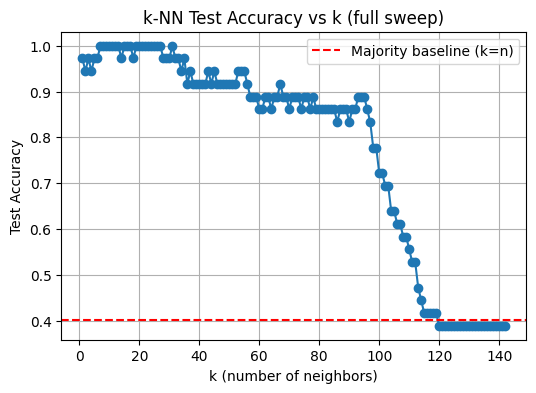

In [ ]:
from collections import Counter

# compute majority baseline (k = n)
majority_acc = max(Counter(train_y.tolist()).values()) / len(train_y)

max_k = len(train_x)  # try up to all training points
accuracies = []

for k in range(1, max_k+1):
    preds = knn_algorithm(train_x, test_x, train_y, k=k)
    acc = (preds == test_y).float().mean().item()
    accuracies.append(acc)

plt.figure(figsize=(6,4))
plt.plot(range(1, max_k+1), accuracies, marker='o')
plt.axhline(majority_acc, color='r', linestyle='--', label="Majority baseline (k=n)")
plt.xlabel("k (number of neighbors)")
plt.ylabel("Test Accuracy")
plt.title("k-NN Test Accuracy vs k (full sweep)")
plt.legend()
plt.grid(True)
plt.show()

# QUESTION 6a:
# a) Where does accuracy peak?
# b) What happens as k approaches the number of training points?
# c) Why does it converge to the majority baseline?


## (b) High-Dimensional Distances

Here we explore why kNN can perform poorly in very high dimensions.

We won’t use labels here — just random points.  
The goal is to see how **pairwise distances behave as dimension grows**.

- In low dimensions (like 10D), some points are close and some are far.  
- In very high dimensions (like 1000D), almost all distances are about the same.  
- If every neighbor looks equally far away, kNN has trouble deciding which points are “nearest.”


/tmp/ipython-input-442272874.py:23: UserWarning: torch.range is deprecated and will be removed in a future release because its behavior is inconsistent with Python's range builtin. Instead, use torch.arange, which produces values in [start, end).
  plt.xticks(torch.range(0, 1.1, 0.1))


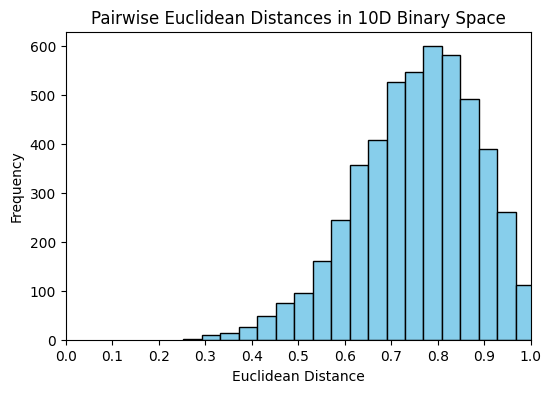

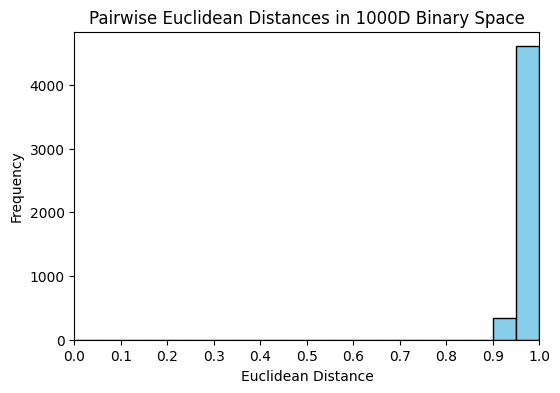

In [ ]:
from itertools import combinations

def distance_histogram(num_vectors=100, dim=100):
    """
    Generate random vectors and plot a histogram of pairwise Euclidean distances.

    Args:
        num_vectors: how many random vectors to generate
        dim: dimensionality of each vector
    """
   # 1. Generate random vectors from 0 to 1
    X = torch.rand((num_vectors, dim), dtype=torch.float32)

    # 2. Compute all pairwise Euclidean distances
    dists = []
    for i, j in combinations(range(num_vectors), 2):
        dist = torch.norm(X[i] - X[j], dim).item()
        dists.append(dist)

    # 3. Plot histogram
    plt.figure(figsize=(6,4))
    plt.hist(dists, bins=20, color='skyblue', edgecolor='black')
    plt.xticks(torch.range(0, 1.1, 0.1))
    plt.xlabel("Euclidean Distance")
    plt.ylabel("Frequency")
    plt.title(f"Pairwise Euclidean Distances in {dim}D Binary Space")
    plt.xlim(0, 1)
    plt.show()

# TODO: Uncomment the code below
distance_histogram(num_vectors=100, dim=10)
distance_histogram(num_vectors=100, dim=1000)

# QUESTION 6b:
# a) What differences do you notice in the two histograms?
# b) Why do the distances concentrate around a single value in high dimensions?
# c) How might this affect kNN's ability to find meaningful neighbors?